<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Toy_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependencies

In [ ]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=30eeb287fda35e3c1182547460995bbfc34ee5b497b247af3769fd8d329c2bf9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
import qiskit
import qiskit.quantum_info as qi
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng() # Random Number Generator

# Stabilizer Entropy

## Explanation

**Gottesman entropy calculation**
* **Restricting the stabilizer generators to a subsystem $A$** yealds $A$'s entropy.
* Some stabilizers remain entirely inside ($A$), while others are "cut" by the partition and connect ($A$) to the rest of the system.
* The **number of independent stabilizers lost across the cut** tells you how much information ($A$) shares with its complement.
* Specifically,

  $
  S(A) = |A| - \operatorname{rank}(G_A),
  $

  where:

  * ($|A|$) is the number of qubits in subsystem ($A$),
  * ($G_A$) is the matrix of stabilizers supported entirely on ($A$).

## GF(2) Rank

**Rank of a binary matrix over GF(2) via Gaussian elimination**

In [ ]:
def gf2_rank(matrix):
    m = (matrix.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col]:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank

## Explanations of the code above

For a binary matrix $(A)$ over $(GF(2))$, the rank is:

$$
\boxed{\operatorname{rank}_{GF(2)}(A)=\text{number of pivot columns after Gaussian elimination over }GF(2)}
$$

$$
\boxed{{GF(2)=\{0,1}\}}
$$

$GF(2)$ is the finite field with two elements, where arithmetic is done modulo (2)



After reducing $(A)$ to **row-echelon form** to eliminate entries below each pivot:

$$
A \xrightarrow{\text{Gaussian elimination over }GF(2)}
\begin{bmatrix}
1&*&*&\\
0&1&*&\\
0&0&1\\
0&0&0
\end{bmatrix}
$$

the rank is the number of nonzero rows (equivalently, the number of pivots).


## Entropy of an Ancilla

In [ ]:
def ancilla_entropy(state, ancilla_col=0):
    """S_A = rank_GF2(stabilizer restricted to A) - |A|, for a 1-qubit ancilla."""
    cliff = state.clifford #Get the Clifford representation
    x_col = cliff.stab_x[:, ancilla_col:ancilla_col+1].astype(np.uint8) #Extract the X stabilizers of ancilla
    z_col = cliff.stab_z[:, ancilla_col:ancilla_col+1].astype(np.uint8) #Extract the Z stabilizers of ancilla
    M_A = np.concatenate([x_col, z_col], axis=1) #Build the restricted stabilizer matrix
    return gf2_rank(M_A) - 1 #Yeald the entropy

This function computes the **entropy of a single ancilla qubit** in a stabilizer state using the stabilizer formalism, which for following formula:

$$
S_A = \operatorname{rank}_{GF(2)}(M_A) - |A|,
$$


* ($M_A$) is the stabilizer generator matrix restricted to subsystem ($A$),
* ($|A|=1$) because the subsystem is a single qubit.



#Random brickwork Clifford

In [ ]:
def brickwork_layer(state, system_qubits, t, periodic=True):
    """One staggered even/odd brickwork layer of random 2-qubit Cliffords."""
    L = len(system_qubits)
    offset = t % 2
    j = offset
    while j + 1 < L:
        u2 = qi.random_clifford(2)
        state = state.evolve(qi.Clifford(u2), qargs=[system_qubits[j], system_qubits[j+1]])
        j += 2
    if periodic and offset == 1 and L % 2 == 0:
        u2 = qi.random_clifford(2)
        state = state.evolve(qi.Clifford(u2), qargs=[system_qubits[L-1], system_qubits[0]])
    return state

This function implements **one layer of a 1D brickwork quantum circuit** made of **random two-qubit Clifford gates**. It applies gates in an alternating even/odd pattern, which is common in quantum information simulations of random circuits, scrambling, and entanglement dynamics.

Let's go line by line.

```python
def brickwork_layer(state, system_qubits, t, periodic=True):
```

Defines a function:

* `state`: the current quantum state (likely a Qiskit `QuantumCircuit`-like state object, e.g. `DensityMatrix` or `Statevector`)
* `system_qubits`: list of qubit indices that form the 1D system
* `t`: the time step / layer number
* `periodic`: whether to use periodic boundary conditions (connect last qubit to first qubit)

Example:

```python
system_qubits = [0,1,2,3,4,5]
t = 0
```

represents a 6-qubit chain.

---

### 1. Get system size

```python
L = len(system_qubits)
```

`L` is the number of qubits.

Example:

```python
system_qubits = [0,1,2,3]
```

gives:

```
L = 4
```

---

### 2. Determine whether this is an even or odd layer

```python
offset = t % 2
```

This alternates between 0 and 1:

| t | offset |
| - | ------ |
| 0 | 0      |
| 1 | 1      |
| 2 | 0      |
| 3 | 1      |

So the circuit alternates:

* even layers: apply gates on `(0,1), (2,3), (4,5), ...`
* odd layers: apply gates on `(1,2), (3,4), (5,6), ...`

This creates the brickwork pattern.

For example:

```
Layer 0:

0──●────
   │
1──●────

2──●────
   │
3──●────


Layer 1:

0────────

1──●────
   │
2──●────

3──●────
   │
4──●────
```

---

### 3. Start at the correct qubit

```python
j = offset
```

If:

```python
offset = 0
```

then:

```python
j = 0
```

and the first pair is:

```
(0,1)
```

If:

```python
offset = 1
```

then:

```python
j = 1
```

and the first pair is:

```
(1,2)
```

---

### 4. Apply random two-qubit Clifford gates

```python
while j + 1 < L:
```

Loop while there is another qubit available to pair with `j`.

Example:

```
L = 6
offset = 0
```

Pairs:

```
(0,1)
(2,3)
(4,5)
```

The loop runs for:

```
j = 0
j = 2
j = 4
```

---

Inside the loop:

```python
u2 = qi.random_clifford(2)
```

Generates a random **two-qubit Clifford operation**.

The Clifford group is the set of quantum operations that map Pauli operators to Pauli operators:

[
CPC^\dagger \in {I,X,Y,Z}
]

for any Pauli operator (P).

A random Clifford is often used because:

* it creates highly entangled states,
* it is efficiently simulatable,
* it mimics chaotic quantum dynamics.

---

Then:

```python
state = state.evolve(
    qi.Clifford(u2),
    qargs=[system_qubits[j], system_qubits[j+1]]
)
```

Applies that random two-qubit gate to the selected neighboring qubits.

Example:

```python
j = 2
```

applies:

```
qubit 2 ───●───
           U
qubit 3 ───●───
```

while leaving all other qubits untouched.

---

Then:

```python
j += 2
```

Move to the next pair.

Example:

```
j=0 → pair (0,1)
j=2 → pair (2,3)
j=4 → pair (4,5)
```

---

## 5. Periodic boundary condition

After the normal nearest-neighbor gates:

```python
if periodic and offset == 1 and L % 2 == 0:
```

This checks three things:

### Condition 1

```python
periodic
```

The user wants periodic boundaries.

Meaning:

```
0──1──2──3
```

becomes:

```
0──1──2──3
|        |
+--------+
```

so qubit 3 also interacts with qubit 0.

---

### Condition 2

```python
offset == 1
```

Only add the wraparound gate on odd layers.

Why?

Because on odd layers:

```
(1,2), (3,4), (5,6) ...
```

there is a leftover edge between the last and first qubits.

Example:

For:

```
L=6
```

odd layer pairs:

```
(1,2)
(3,4)
```

leaves:

```
5 and 0
```

unpaired.

So we add:

```
(5,0)
```

---

### Condition 3

```python
L % 2 == 0
```

Only works cleanly for an even number of qubits.

For example:

```
L=6

1---2
3---4
5---0
```

covers everyone.

But for:

```
L=5
```

a perfect matching is impossible.

---

The wraparound gate:

```python
u2 = qi.random_clifford(2)

state = state.evolve(
    qi.Clifford(u2),
    qargs=[system_qubits[L-1], system_qubits[0]]
)
```

applies a random Clifford between the last and first qubit.

Example:

```
5 ───U─── 0
```

---

### 6. Return updated state

```python
return state
```

The resulting quantum state after one brickwork layer.

---

## Overall picture

For 8 qubits:

### Layer `t=0`

```
0====1     2====3     4====5     6====7
```

Random Clifford gates:

[
U_{0,1}\otimes U_{2,3}\otimes U_{4,5}\otimes U_{6,7}
]

### Layer `t=1`

```
7====0     1====2     3====4     5====6
```

Random Clifford gates:

[
U_{7,0}\otimes U_{1,2}\otimes U_{3,4}\otimes U_{5,6}
]

Repeating:

```python
for t in range(T):
    state = brickwork_layer(state, qubits, t)
```

creates a **random Clifford brickwork circuit**.

---

### Where this is commonly used

This type of circuit appears in simulations of:

* **quantum scrambling**
* **operator spreading**
* **entanglement growth**
* **random unitary circuits**
* **measurement-induced phase transitions**
* **quantum many-body chaos**

The key idea is that each layer locally entangles neighbors, and the alternating pattern allows information to propagate across the whole chain over time.


# Rest

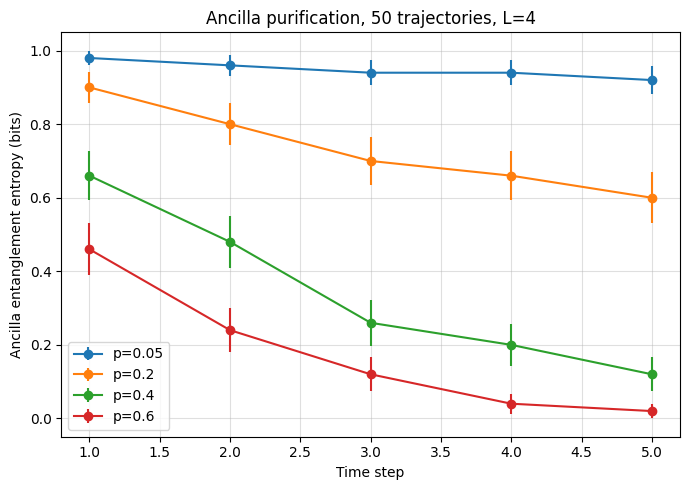

In [ ]:


def measure_layer(state, system_qubits, p_measure):
    """Independently measure EACH system qubit with probability p_measure."""
    for q in system_qubits:
        if rng.random() < p_measure:
            _, state = state.measure([q])
    return state

def run_trajectory(size, T, p_measure, t_scramble=0, periodic=True):
    Ancilla = qiskit.QuantumRegister(1, 'ancilla')
    System = qiskit.QuantumRegister(size, 'system')
    qc = qiskit.QuantumCircuit(Ancilla, System)
    system_qubits = list(range(1, size + 1))  # global indices; ancilla = 0

    if t_scramble > 0:
        # Phase 1: scramble the system ALONE, no ancilla coupling yet
        qc_sys = qiskit.QuantumCircuit(size)
        state = qi.StabilizerState(qc_sys)
        for t in range(t_scramble):
            state = brickwork_layer(state, list(range(size)), t, periodic=periodic)
        # rebuild as (ancilla + system), then couple
        full_qc = qiskit.QuantumCircuit(Ancilla, System)
        state = qi.StabilizerState(full_qc).evolve(qi.Clifford(state.clifford.to_circuit()),
                                                  qargs=list(range(1, size + 1)))
        state = state.evolve(qi.Clifford(qiskit.QuantumCircuit(1).compose(qiskit.QuantumCircuit(1))), qargs=[0])  # no-op, ancilla stays |0>
        qc2 = qiskit.QuantumCircuit(1)
        qc2.h(0)
        state = state.evolve(qi.Clifford(qc2), qargs=[0])
        cx = qiskit.QuantumCircuit(2); cx.cx(0, 1)
        state = state.evolve(qi.Clifford(cx), qargs=[0, size // 2 + 1])
    else:
        qc.h(Ancilla)
        qc.cx(Ancilla, System[size // 2])
        state = qi.StabilizerState(qc)

    entropy_history = np.zeros(T)
    for t in range(T):
        state = brickwork_layer(state, system_qubits, t, periodic=periodic)
        state = measure_layer(state, system_qubits, p_measure)
        entropy_history[t] = ancilla_entropy(state, ancilla_col=0)
    return entropy_history

def run_averaged(size, T, p_measure, n_trials=200, t_scramble=0, periodic=True):
    all_S = np.zeros((n_trials, T))
    for k in range(n_trials):
        all_S[k] = run_trajectory(size, T, p_measure, t_scramble=t_scramble, periodic=periodic)
    return all_S.mean(axis=0), all_S.std(axis=0) / np.sqrt(n_trials)

# --- Run and plot ---
size = 4          # even size -> clean periodic brickwork, matches the paper's 2L convention
T = 5
n_trials = 50

plt.figure(figsize=(7, 5))
for p in [0.05, 0.2, 0.4, 0.6]:
    mean_S, sem_S = run_averaged(size, T, p, n_trials=n_trials)
    plt.errorbar(range(1, T + 1), mean_S, yerr=sem_S, marker='o', label=f"p={p}")

plt.xlabel("Time step")
plt.ylabel("Ancilla entanglement entropy (bits)")
plt.title(f"Ancilla purification, {n_trials} trajectories, L={size}")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()